<a href="https://colab.research.google.com/github/zakaria-a-khan/zakaria-a-khan.github.io/blob/main/Quantum_Espresso_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install the Quantum Espresso Binary

In [1]:
%%capture
# Clone the QE git
!git clone https://github.com/QEF/q-e.git
# Install the dependencies
!apt-get install -y libfftw3-3 libfftw3-dev libfftw3-doc
# enter the q-e folder
%cd q-e
# run the configure file
# !DFLAGS='-D__OPENMP -D__FFTW3 -D__MPI -D__SCALAPACK' FFT_LIBS='-lfftw3'  ./configure --enable-openmp
!!DFLAGS='-D__FFTW3 ' FFT_LIBS='-lfftw3'  ./configure
# computation time ~1 minute

\Install `ase` for preparing input files, reading output files and visualization

In [2]:
%%capture
!apt install ase #computation time ~30 seconds

Run the cell to make `pw.x` binary
If you need to make any other binary like `dos.x` or `bands.x`. Replace the `pw` with `dos` or `bands`

In [3]:
%%capture
!make pw #computation time ~5-7 minutes

In [4]:
!mkdir -p /content/silicon

:Create a folder named "silicon" to download and keep all the files needed including the input files and pseudopotential files.

After creating the folder, upload the pseudopotential file in this folder.

In [5]:
# Navigating into your folder.
%cd /content/silicon/

/content/silicon


# Prepare the input file

In [6]:
qe_input = """
&control
  prefix='silicon',
  ! this is a comment: you can comment out variables
  ! set pseudo_dir and outdir to suitable directories
  pseudo_dir = '/content/silicon/',
  outdir='/content/silicon/'
/
&system
  ibrav = 2, celldm(1) = 10.7, nat = 2, ntyp = 1,
  ecutwfc = 30.0,
/
&electrons
/
ATOMIC_SPECIES
 Si  28.086  Si.pz-vbc.UPF
ATOMIC_POSITIONS alat
 Si 0.00 0.00 0.00
 Si 0.25 0.25 0.25
! this is a comment
K_POINTS automatic
   4 4 4 1 1 1
"""

# We write the input script
with open("si.scf.in", "w") as f:
    f.write(qe_input)

Visualize the silicon atoms

In [8]:
from ase.io.espresso import read_espresso_in
from ase.visualize import view

# Read the QE input file
atoms = read_espresso_in(open("si.scf.in"))

# Visualize it in 3D
view(atoms, viewer='x3d')

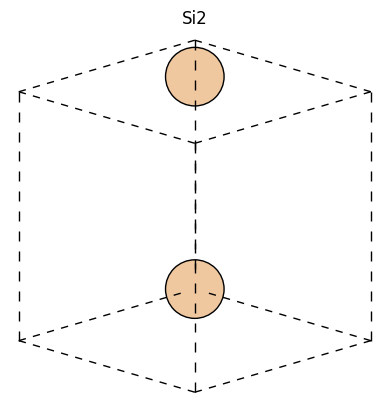

In [9]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

fig, ax = plt.subplots()
plot_atoms(atoms, ax, radii=0.3, rotation=('45x,45y,90z'))
ax.set_title(atoms.get_chemical_formula())
ax.set_axis_off()
plt.show()

# Run the DFT code

Note: Check the directories for pseudopotential file and output file!

In [16]:
%cd /content/silicon/

/content/silicon


In [17]:
!ls -l

total 220
-rw-r--r-- 1 root root 215315 Apr  1 23:56 Si.pz-vbc.UPF
-rw-r--r-- 1 root root    451 Apr  1 23:50 si.scf.in
-rw-r--r-- 1 root root   1332 Apr  1 23:56 si.scf.out


In [18]:
!wget https://www.quantum-espresso.org/upf_files/Si.pz-vbc.UPF

--2025-04-01 23:58:06--  https://www.quantum-espresso.org/upf_files/Si.pz-vbc.UPF
Resolving www.quantum-espresso.org (www.quantum-espresso.org)... 51.77.118.191
Connecting to www.quantum-espresso.org (www.quantum-espresso.org)|51.77.118.191|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: / [following]
--2025-04-01 23:58:07--  https://www.quantum-espresso.org/
Reusing existing connection to www.quantum-espresso.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Si.pz-vbc.UPF.1’

Si.pz-vbc.UPF.1         [  <=>               ] 210.27K   684KB/s    in 0.3s    

2025-04-01 23:58:08 (684 KB/s) - ‘Si.pz-vbc.UPF.1’ saved [215315]



In [19]:
!ls -l

total 432
-rw-r--r-- 1 root root 215315 Apr  1 23:56 Si.pz-vbc.UPF
-rw-r--r-- 1 root root 215315 Apr  1 23:58 Si.pz-vbc.UPF.1
-rw-r--r-- 1 root root    451 Apr  1 23:50 si.scf.in
-rw-r--r-- 1 root root   1332 Apr  1 23:56 si.scf.out


In [20]:
%cd /content/silicon/

/content/silicon


In [21]:
!rm Si.pz-vbc.UPF.1

In [22]:
! /content/q-e/bin/pw.x -in si.scf.in > si.scf.out

STOP 1


In [23]:
!tail -n 30 si.scf.out

     Program PWSCF v.7.4.1 starts on  1Apr2025 at 23:59:55 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Serial version
     7161 MiB available memory on the printing compute node when the environment starts

     Reading input from si.scf.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4
 xmlr_opentag: severe error, line too long
     read_ncpp: PP file is empty or wrong

In [24]:
!rm Si.pz-vbc.UPF

In [25]:
!wget -O Si.pz-vbc.UPF https://pseudopotentials.quantum-espresso.org/upf_files/Si.pz-vbc.UPF

--2025-04-02 00:00:52--  https://pseudopotentials.quantum-espresso.org/upf_files/Si.pz-vbc.UPF
Resolving pseudopotentials.quantum-espresso.org (pseudopotentials.quantum-espresso.org)... 51.77.118.191
Connecting to pseudopotentials.quantum-espresso.org (pseudopotentials.quantum-espresso.org)|51.77.118.191|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74552 (73K)
Saving to: ‘Si.pz-vbc.UPF’

Si.pz-vbc.UPF       100%[===================>]  72.80K   313KB/s    in 0.2s    

2025-04-02 00:00:53 (313 KB/s) - ‘Si.pz-vbc.UPF’ saved [74552/74552]



In [26]:
!head -n 10 Si.pz-vbc.UPF

<UPF version="2.0.1">
<PP_INFO>
Generated by new atomic code, or converted to UPF format
Author:
Generation date:
Pseudopotential type: NC
Element: Si
Functional:  SLA  PZ   NOGX NOGC
Suggested minimum cutoff for wavefunctions:   0. Ry
Suggested minimum cutoff for charge density:   0. Ry


In [27]:
! /content/q-e/bin/pw.x -in si.scf.in > si.scf.out

In [28]:
!tail -n 20 si.scf.out

     h_psi:calbec :      0.01s CPU      0.02s WALL (     168 calls)
     vloc_psi     :      0.36s CPU      0.36s WALL (     168 calls)
                                        0.00s GPU  (     168 calls)
     add_vuspsi   :      0.00s CPU      0.00s WALL (     168 calls)

     General routines
     calbec       :      0.00s CPU      0.02s WALL (     168 calls)
     fft          :      0.15s CPU      0.16s WALL (      15 calls)
     ffts         :      0.00s CPU      0.00s WALL (       5 calls)
     fftw         :      0.34s CPU      0.35s WALL (    1426 calls)


     PWSCF        :      0.70s CPU      0.87s WALL


   This run was terminated on:   0: 1:46   2Apr2025            

=------------------------------------------------------------------------------=
   JOB DONE.
=------------------------------------------------------------------------------=


# See the output file

In [29]:
!grep "!" si.scf.out

!    total energy              =     -15.83687864 Ry


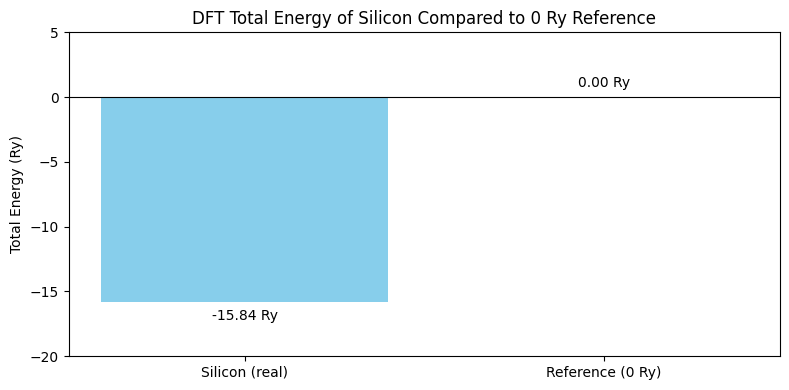

In [36]:
import matplotlib.pyplot as plt

labels = ['Silicon (real)', 'Reference (0 Ry)']
energies = [-15.83687864, 0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, energies, color=['skyblue', 'lightgray'])

# Force the y-axis to show a large range so it doesn't auto-scale to just the bar
ax.set_ylim(-20, 5)

# Add a horizontal zero line
ax.axhline(0, color='black', linewidth=0.8)

# Add bar labels
ax.bar_label(bars, fmt='%.2f Ry', padding=5)

ax.set_ylabel('Total Energy (Ry)')
ax.set_title('DFT Total Energy of Silicon Compared to 0 Ry Reference')
plt.tight_layout()
plt.show()

In this project, I used Quantum ESPRESSO on Google Colab to perform a DFT calculation of crystalline silicon. I successfully modified the provided notebook to define a new input file, downloaded the appropriate pseudopotential, and ran a self-consistent field (SCF) calculation. I visualized the atomic structure in both 3D and 2D, and created a custom 2D bar graph showing the total energy of the system, which was calculated to be –15.84 Rydbergs. This result was expected, as stable crystal structures should have large negative total energies, indicating strong bonding and system stability. Modifying the notebook was moderately challenging — the main difficulties came from pseudopotential download errors and output interpretation, but these were resolved with some debugging and reconfiguration. I would like to use Colab/Jupyter in future research for prototyping simulations, quickly testing structural models, and sharing reproducible workflows for quantum chemistry and materials modeling.

In [15]:
!cat si.scf.out


     Program PWSCF v.7.4.1 starts on  1Apr2025 at 23:56:28 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Serial version
     7167 MiB available memory on the printing compute node when the environment starts

     Reading input from si.scf.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4
 xmlr_opentag: severe error, line too long
     read_ncpp: PP file is empty or wron

In [ ]:
!grep -e "total energy" -e estimate si.scf.out

     total energy              =     -15.83474059 Ry
     estimated scf accuracy    <       0.04725160 Ry
     total energy              =     -15.83654591 Ry
     estimated scf accuracy    <       0.00215073 Ry
     total energy              =     -15.83684221 Ry
     estimated scf accuracy    <       0.00004787 Ry
!    total energy              =     -15.83687864 Ry
     estimated scf accuracy    <       0.00000003 Ry
     The total energy is the sum of the following terms:


In [ ]:
import ase.io
output = ase.io.read("/content/silicon/si.scf.out")
output.get_total_energy()

-215.47169195270104

# Convergence test

In [ ]:
import numpy as np
# create a list for cutoff energies to be tested
cutoff_energies = np.arange(12,44,4)
# find the "cutoff energy" line in the input file
cutoff_index = qe_input.find('ecutwfc = ') + 10

total_energies = []
for cutoff in cutoff_energies:
  # update the input file with the new cutoff energy
  new_input_file = qe_input[:cutoff_index] + str(cutoff) + qe_input[cutoff_index+4:]
  # overwrite the input file
  with open("si.scf.in", "w") as f:
    f.write(new_input_file)

  ! /content/q-e/bin/pw.x  -in si.scf.in > si.scf.out # run the DFT input file

  output = ase.io.read("/content/silicon/si.scf.out") # read the output file

  total_energies.append(output.get_total_energy()) # record the calculated total energy

# computation time: ~14 seconds

Text(0, 0.5, 'Total Energy (eV)')

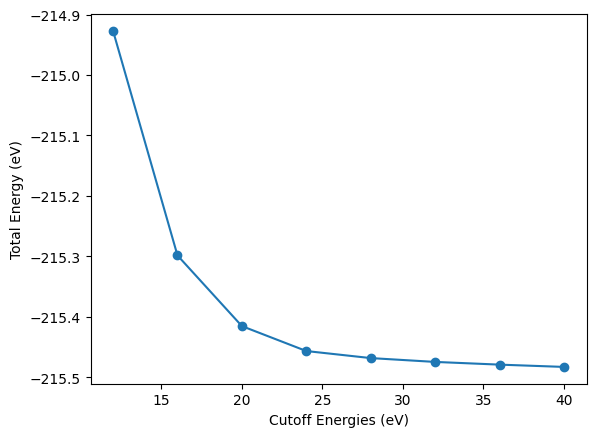

In [ ]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()

ax.plot(cutoff_energies, total_energies,'o-')
ax.set_xlabel('Cutoff Energies (eV)')
ax.set_ylabel('Total Energy (eV)')

# Lattice parameter

In [ ]:
import numpy as np
# create a list for lattice constants to be tested
lattice_constants = np.arange(9.5,11.1,0.1)
# find the "lattice constant" line in the input file
lat_cons_index = qe_input.find('celldm(1) =') + 11

total_energies = []
for constant in lattice_constants:
  # update the input file with the new lattice constant
  new_input_file = qe_input[:lat_cons_index] + str(constant) + qe_input[lat_cons_index+4:]
  # overwrite the input file
  with open("si.scf.in", "w") as f:
    f.write(new_input_file)

  ! /content/q-e/bin/pw.x  -in si.scf.in > si.scf.out # run the DFT input file

  output = ase.io.read("/content/silicon/si.scf.out") # read the output file

  total_energies.append(output.get_total_energy()) # record the calculated total energy

# computation time: 10 seconds

Text(0, 0.5, 'Total Energy (eV)')

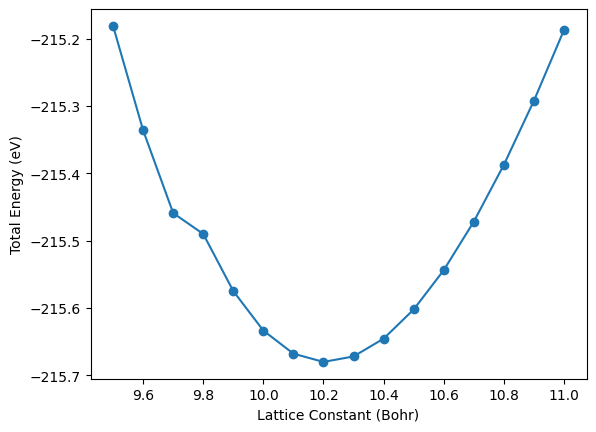

In [ ]:
fig,ax = plt.subplots()

ax.plot(lattice_constants, total_energies,'o-')
ax.set_xlabel('Lattice Constant (Bohr)')
ax.set_ylabel('Total Energy (eV)')

# k-points

In [ ]:
import numpy as np
# create a list for k points to be tested
kpoints = np.arange(1,6,1) # enter kpoints limits
# find the "lattice constant" line in the input file
lat_cons_index = qe_input.find('K_POINTS') + 20

total_energies = []
for k in kpoints:
  # update the input file with the new lattice constant
  new_input_file = qe_input[:lat_cons_index] + str(k).ljust(2) + str(k).ljust(2) + str(k).ljust(2) + qe_input[lat_cons_index+8:]
  # overwrite the input file
  with open("si.scf.in", "w") as f:
    f.write(new_input_file)

  ! /content/q-e/bin/pw.x  -in si.scf.in > si.scf.out # run the DFT input file

  output = ase.io.read("/content/silicon/si.scf.out") # read the output file

  total_energies.append(output.get_total_energy()) # record the calculated total energy

# computation time: 10 seconds

Text(0, 0.5, 'Total Energy (eV)')

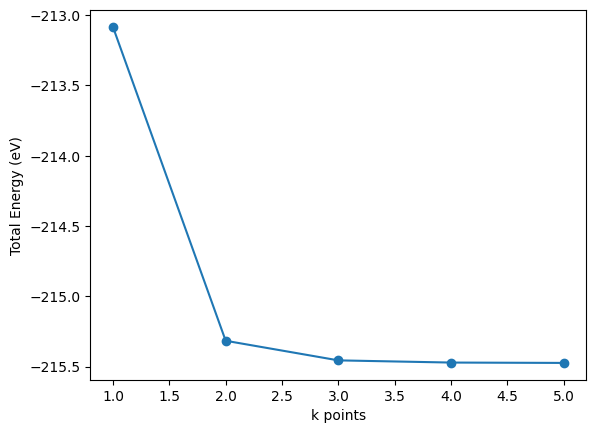

In [ ]:
fig,ax = plt.subplots()

ax.plot(kpoints, total_energies,'o-')
ax.set_xlabel('k points')
ax.set_ylabel('Total Energy (eV)')